In [ ]:
# LIBRARY IMPORTS AND VERSION CHECK

import tensorflow as tf
import sklearn
import pandas as pd
import cv2
import numpy as np

print("=" * 80)
print("LIBRARY VERSIONS")
print("=" * 80)

print("TensorFlow:", tf.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

DATASET OVERVIEW

Dataset Shape : (220025, 2)

Column Names
['id', 'label']

First Five Records


,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0



DATA TYPES


id         str
label    int64
dtype: object


STATISTICAL SUMMARY


...

id       0
label    0
dtype: int64


Total Missing Values : 0

DUPLICATE RECORD ANALYSIS
Duplicate Records : 0

TARGET VARIABLE DISTRIBUTION


label
0    130908
1     89117
Name: count, dtype: int64


Percentage Distribution


label
0    59.5
1    40.5
Name: proportion, dtype: float64

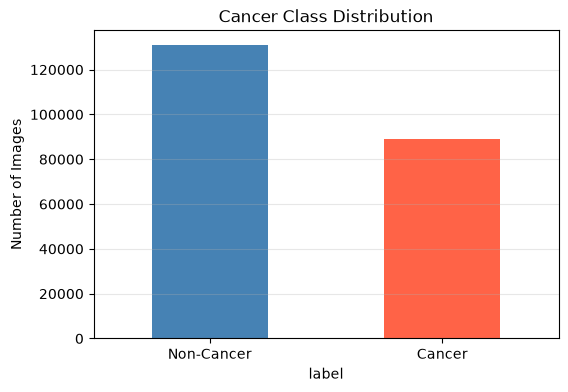


IMAGE FILE VERIFICATION


exists
True    220025
Name: count, dtype: int64


Missing Image Files : 0

RANDOM IMAGE VISUALISATION


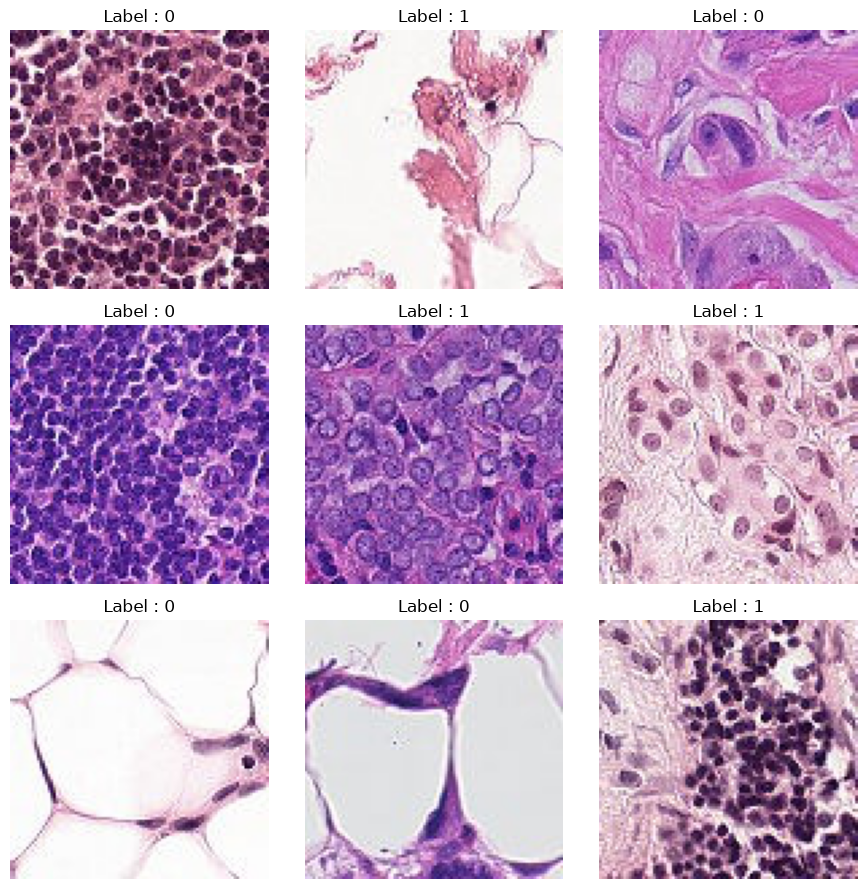


IMAGE DIMENSION VERIFICATION


(96, 96)    500
Name: count, dtype: int64


IMAGE MODE VERIFICATION


RGB    500
Name: count, dtype: int64


PIXEL VALUE ANALYSIS
Minimum Pixel Value : 0
Maximum Pixel Value : 255
Mean Pixel Value    : 165.22
Std Pixel Value     : 66.61

RGB CHANNEL STATISTICS

Red
Mean : 179.52
Std  : 61.76

Green
Mean : 139.48
Std  : 72.91

Blue
Mean : 176.65
Std  : 56.40

CORRUPTED IMAGE CHECK
Corrupted Images Found : 0

DATA QUALITY SUMMARY


,Property,Value
0,Dataset Shape,"(220025, 4)"
1,Number of Features,4
2,Missing Values,0
3,Duplicate Records,0
4,Missing Image Files,0
5,Corrupted Images,0
6,Image Size,"(96, 96)"
7,Image Mode,RGB
8,Pixel Range,0 - 255
9,Target Classes,2



EDA COMPLETED SUCCESSFULLY


In [ ]:
# DATA UNDERSTANDING (EXPLORATORY DATA ANALYSIS)

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8,5)


# Dataset Paths

DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

LABELS_PATH = os.path.join(DATASET_PATH, "train_labels.csv")

IMAGE_FOLDER = DATASET_PATH


# Load Dataset


labels = pd.read_csv(LABELS_PATH)

print("="*80)
print("DATASET OVERVIEW")
print("="*80)

print(f"\nDataset Shape : {labels.shape}")

print("\nColumn Names")

print(labels.columns.tolist())

print("\nFirst Five Records")

display(labels.head())

# Data Types


print("\n" + "="*80)
print("DATA TYPES")
print("="*80)

display(labels.dtypes)


# Statistical Summary


print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

display(labels.describe(include="all"))


# Missing Values


print("\n" + "="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

missing = labels.isnull().sum()

display(missing)

print(f"\nTotal Missing Values : {missing.sum()}")


# Duplicate Records


print("\n" + "="*80)
print("DUPLICATE RECORD ANALYSIS")
print("="*80)

duplicates = labels.duplicated().sum()

print(f"Duplicate Records : {duplicates}")


# Target Variable Distribution


print("\n" + "="*80)
print("TARGET VARIABLE DISTRIBUTION")
print("="*80)

display(labels["label"].value_counts())

print("\nPercentage Distribution")

display(
    round(labels["label"].value_counts(normalize=True)*100,2)
)


# Class Distribution Plot


plt.figure(figsize=(6,4))

labels["label"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue","tomato"]
)

plt.xticks([0,1],["Non-Cancer","Cancer"],rotation=0)

plt.ylabel("Number of Images")

plt.title("Cancer Class Distribution")

plt.grid(axis="y",alpha=0.3)

plt.show()


# Verify Image Files


print("\n" + "="*80)
print("IMAGE FILE VERIFICATION")
print("="*80)

labels["filepath"] = labels["id"].apply(
    lambda x: os.path.join(IMAGE_FOLDER,f"{x}.tif")
)

labels["exists"] = labels["filepath"].apply(os.path.exists)

display(labels["exists"].value_counts())

missing_files = (~labels["exists"]).sum()

print(f"\nMissing Image Files : {missing_files}")


# Random Image Inspection


print("\n" + "="*80)
print("RANDOM IMAGE VISUALISATION")
print("="*80)

sample = labels.sample(9,random_state=42)

fig,axes = plt.subplots(3,3,figsize=(9,9))

for ax,(_,row) in zip(axes.flatten(),sample.iterrows()):

    img = Image.open(row["filepath"])

    ax.imshow(img)

    ax.set_title(
        f"Label : {row['label']}"
    )

    ax.axis("off")

plt.tight_layout()

plt.show()


# Image Dimension Verification


print("\n" + "="*80)
print("IMAGE DIMENSION VERIFICATION")
print("="*80)

sizes=[]

for fp in labels["filepath"].sample(500,random_state=42):

    img=Image.open(fp)

    sizes.append(img.size)

sizes=pd.Series(sizes)

display(sizes.value_counts())


# Image Mode Verification


print("\n" + "="*80)
print("IMAGE MODE VERIFICATION")
print("="*80)

modes=[]

for fp in labels["filepath"].sample(500,random_state=42):

    img=Image.open(fp)

    modes.append(img.mode)

display(pd.Series(modes).value_counts())


# Pixel Statistics


print("\n" + "="*80)
print("PIXEL VALUE ANALYSIS")
print("="*80)

pixels=[]

for fp in labels["filepath"].sample(100,random_state=42):

    img=np.array(Image.open(fp))

    pixels.append(img)

pixels=np.concatenate(
    [x.reshape(-1,3) for x in pixels],
    axis=0
)

print(f"Minimum Pixel Value : {pixels.min()}")

print(f"Maximum Pixel Value : {pixels.max()}")

print(f"Mean Pixel Value    : {pixels.mean():.2f}")

print(f"Std Pixel Value     : {pixels.std():.2f}")


# RGB Channel Statistics


print("\n" + "="*80)
print("RGB CHANNEL STATISTICS")
print("="*80)

channels=["Red","Green","Blue"]

for i,c in enumerate(channels):

    print(f"\n{c}")

    print(f"Mean : {pixels[:,i].mean():.2f}")

    print(f"Std  : {pixels[:,i].std():.2f}")

# Corrupted Image Detection


print("\n" + "="*80)
print("CORRUPTED IMAGE CHECK")
print("="*80)

corrupted=[]

for fp in labels["filepath"].sample(1000,random_state=42):

    try:

        Image.open(fp).verify()

    except:

        corrupted.append(fp)

print(f"Corrupted Images Found : {len(corrupted)}")


# Dataset Quality Summary


print("\n" + "="*80)
print("DATA QUALITY SUMMARY")
print("="*80)

summary=pd.DataFrame({

    "Property":[

        "Dataset Shape",
        "Number of Features",
        "Missing Values",
        "Duplicate Records",
        "Missing Image Files",
        "Corrupted Images",
        "Image Size",
        "Image Mode",
        "Pixel Range",
        "Target Classes"

    ],

    "Value":[

        labels.shape,
        labels.shape[1],
        missing.sum(),
        duplicates,
        missing_files,
        len(corrupted),
        sizes.iloc[0],
        modes[0],
        f"{pixels.min()} - {pixels.max()}",
        labels["label"].nunique()

    ]

})

display(summary)

print("\nEDA COMPLETED SUCCESSFULLY")

DATA PREPROCESSING
Total Images : 220,025

STEP 1 : IMAGE LOADING
Image Mode      : RGB
Original Size   : (96, 96)
Image Format    : TIFF

STEP 2 : IMAGE RESIZING
Target Size : (224, 224)

STEP 3 : PIXEL NORMALISATION
Pixel values will be scaled from [0,255] to [0,1].

STEP 4 : DATA AUGMENTATION

STEP 5 : STRATIFIED DATASET SPLITTING
Training Images   : 154,017
Validation Images : 33,004
Testing Images    : 33,004

Class Distribution (%)


,Training,Validation,Testing
label,,,
0,59.5,59.5,59.5
1,40.5,40.5,40.5



Class Weights
{0: np.float64(0.8403830414143068), 1: np.float64(1.2344666730787728)}

STEP 6 : BATCH GENERATION
Found 154017 validated image filenames.
Found 33004 validated image filenames.
Found 33004 validated image filenames.

STEP 7 : PREPROCESSING VERIFICATION
Batch Shape      : (32, 224, 224, 3)
Label Shape      : (32,)
Pixel Range      : 0.000 - 1.000


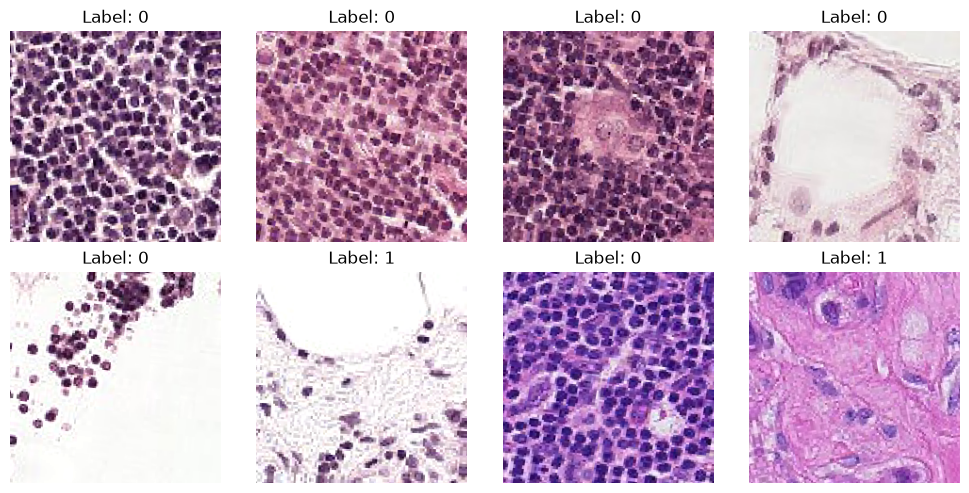


PREPROCESSING SUMMARY



,Operation,Configuration
0,Image Loading,Histopathology RGB Images
1,Image Resizing,224 × 224
2,Pixel Normalisation,Rescale = 1/255
3,Data Augmentation,"Rotation, Horizontal Flip, Zoom, Brightness"
4,Dataset Split,70% Train | 15% Validation | 15% Test
5,Batch Size,32
6,Class Weighting,Balanced Class Weights



Data preprocessing completed successfully.

STEP 8 : SAVING PREPROCESSING OUTPUTS

Preprocessing artefacts successfully saved.

Location : C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata\Processed_Data

Saved Files
✓ train.csv
✓ validation.csv
✓ test.csv
✓ class_weights.csv
✓ preprocessing_configuration.csv
✓ preprocessing_summary.csv

The saved preprocessing outputs will be reused throughout
feature extraction, model development, training,
evaluation, and comparative analysis to ensure
experimental consistency and reproducibility.


In [ ]:
# DATA PREPROCESSING

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")


# Dataset Paths


DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

LABELS_PATH = os.path.join(DATASET_PATH, "train_labels.csv")

IMAGE_FOLDER = DATASET_PATH

IMAGE_SIZE = (224,224)

BATCH_SIZE = 32


# Load Dataset


labels = pd.read_csv(LABELS_PATH)

labels["filepath"] = labels["id"].apply(
    lambda x: os.path.join(IMAGE_FOLDER, f"{x}.tif")
)

print("="*80)
print("DATA PREPROCESSING")
print("="*80)

print(f"Total Images : {len(labels):,}")


# STEP 1 — IMAGE LOADING


print("\nSTEP 1 : IMAGE LOADING")

sample_image = Image.open(labels.loc[0, "filepath"])

print(f"Image Mode      : {sample_image.mode}")

print(f"Original Size   : {sample_image.size}")

print(f"Image Format    : {sample_image.format}")


# STEP 2 — IMAGE RESIZING


print("\nSTEP 2 : IMAGE RESIZING")

print(f"Target Size : {IMAGE_SIZE}")


# STEP 3 — PIXEL NORMALISATION


print("\nSTEP 3 : PIXEL NORMALISATION")

print("Pixel values will be scaled from [0,255] to [0,1].")


# STEP 4 — DATA AUGMENTATION

print("\nSTEP 4 : DATA AUGMENTATION")

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=10,

    horizontal_flip=True,

    zoom_range=0.10,

    brightness_range=(0.95,1.05),

    fill_mode="reflect"

)

validation_datagen = ImageDataGenerator(

    rescale=1./255

)

test_datagen = ImageDataGenerator(

    rescale=1./255

)


# STEP 5 — STRATIFIED DATASET SPLITTING


print("\nSTEP 5 : STRATIFIED DATASET SPLITTING")

train_df, temp_df = train_test_split(

    labels,

    test_size=0.30,

    stratify=labels["label"],

    random_state=42

)

validation_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    stratify=temp_df["label"],

    random_state=42

)

print(f"Training Images   : {len(train_df):,}")

print(f"Validation Images : {len(validation_df):,}")

print(f"Testing Images    : {len(test_df):,}")

print("\nClass Distribution (%)")

distribution = pd.DataFrame({

    "Training":

        round(train_df["label"].value_counts(normalize=True)*100,2),

    "Validation":

        round(validation_df["label"].value_counts(normalize=True)*100,2),

    "Testing":

        round(test_df["label"].value_counts(normalize=True)*100,2)

})

display(distribution)


# Compute Class Weights


weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(train_df["label"]),

    y=train_df["label"]

)

class_weights = dict(enumerate(weights))

print("\nClass Weights")

print(class_weights)


# STEP 6 — BATCH GENERATION


print("\nSTEP 6 : BATCH GENERATION")

train_generator = train_datagen.flow_from_dataframe(

    dataframe=train_df,

    x_col="filepath",

    y_col="label",

    target_size=IMAGE_SIZE,

    class_mode="raw",

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=42

)

validation_generator = validation_datagen.flow_from_dataframe(

    dataframe=validation_df,

    x_col="filepath",

    y_col="label",

    target_size=IMAGE_SIZE,

    class_mode="raw",

    batch_size=BATCH_SIZE,

    shuffle=False

)

test_generator = test_datagen.flow_from_dataframe(

    dataframe=test_df,

    x_col="filepath",

    y_col="label",

    target_size=IMAGE_SIZE,

    class_mode="raw",

    batch_size=BATCH_SIZE,

    shuffle=False

)


# STEP 7 — PREPROCESSING VERIFICATION


print("\nSTEP 7 : PREPROCESSING VERIFICATION")

images, labels_batch = next(train_generator)

print(f"Batch Shape      : {images.shape}")

print(f"Label Shape      : {labels_batch.shape}")

print(f"Pixel Range      : {images.min():.3f} - {images.max():.3f}")

fig, axes = plt.subplots(2,4, figsize=(10,5))

for ax, img, lbl in zip(axes.flatten(), images[:8], labels_batch[:8]):

    ax.imshow(img)

    ax.set_title(f"Label: {int(lbl)}")

    ax.axis("off")

plt.tight_layout()

plt.show()


# PREPROCESSING SUMMARY


summary = pd.DataFrame({

    "Operation":[

        "Image Loading",

        "Image Resizing",

        "Pixel Normalisation",

        "Data Augmentation",

        "Dataset Split",

        "Batch Size",

        "Class Weighting"

    ],

    "Configuration":[

        "Histopathology RGB Images",

        "224 × 224",

        "Rescale = 1/255",

        "Rotation, Horizontal Flip, Zoom, Brightness",

        "70% Train | 15% Validation | 15% Test",

        BATCH_SIZE,

        "Balanced Class Weights"

    ]

})

print("\nPREPROCESSING SUMMARY\n")

display(summary)

print("\nData preprocessing completed successfully.")



# STEP 8 — SAVE PREPROCESSING OUTPUTS


print("\nSTEP 8 : SAVING PREPROCESSING OUTPUTS")

# Create output directory
OUTPUT_DIR = os.path.join(DATASET_PATH, "Processed_Data")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Save train / validation / test splits


train_df.to_csv(
    os.path.join(OUTPUT_DIR, "train.csv"),
    index=False
)

validation_df.to_csv(
    os.path.join(OUTPUT_DIR, "validation.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(OUTPUT_DIR, "test.csv"),
    index=False
)


# Save class weights


class_weight_df = pd.DataFrame({

    "Class": list(class_weights.keys()),
    "Weight": list(class_weights.values())

})

class_weight_df.to_csv(

    os.path.join(OUTPUT_DIR, "class_weights.csv"),

    index=False

)


# Save preprocessing configuration


preprocessing_config = pd.DataFrame({

    "Parameter":[

        "Image Size",

        "Batch Size",

        "Normalisation",

        "Rotation",

        "Horizontal Flip",

        "Zoom",

        "Brightness",

        "Training Split",

        "Validation Split",

        "Testing Split"

    ],

    "Value":[

        "224 x 224",

        BATCH_SIZE,

        "Pixel / 255",

        "20°",

        "Enabled",

        "0.20",

        "0.90–1.10",

        "70%",

        "15%",

        "15%"

    ]

})

preprocessing_config.to_csv(

    os.path.join(OUTPUT_DIR, "preprocessing_configuration.csv"),

    index=False

)


# Save preprocessing summary


summary.to_csv(

    os.path.join(OUTPUT_DIR, "preprocessing_summary.csv"),

    index=False

)


# Confirmation


print("\nPreprocessing artefacts successfully saved.\n")

print(f"Location : {OUTPUT_DIR}")

print("\nSaved Files")

saved_files = [

    "train.csv",

    "validation.csv",

    "test.csv",

    "class_weights.csv",

    "preprocessing_configuration.csv",

    "preprocessing_summary.csv"

]

for file in saved_files:

    print(f"✓ {file}")

print("\nThe saved preprocessing outputs will be reused throughout")
print("feature extraction, model development, training,")
print("evaluation, and comparative analysis to ensure")
print("experimental consistency and reproducibility.")

In [ ]:
# FEATURE EXTRACTION

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")



# DATASET PATHS


DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

PROCESSED_PATH = os.path.join(DATASET_PATH, "Processed_Data")

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32



# LOAD PREPROCESSED DATA


print("="*80)
print("FEATURE EXTRACTION")
print("="*80)

train_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "train.csv")
)

validation_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "validation.csv")
)

test_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "test.csv")
)

class_weight_df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "class_weights.csv")
)

print(f"Training Images   : {len(train_df):,}")
print(f"Validation Images : {len(validation_df):,}")
print(f"Testing Images    : {len(test_df):,}")

display(class_weight_df)


# CREATE STRATIFIED EXPERIMENTAL SUBSET


print("="*80)
print("CREATING STRATIFIED EXPERIMENTAL SUBSET")
print("="*80)

from sklearn.model_selection import train_test_split

TRAIN_SIZE = 25000
VALIDATION_SIZE = 5000
TEST_SIZE = 5000


# Training subset


train_df, _ = train_test_split(

    train_df,

    train_size=TRAIN_SIZE,

    stratify=train_df["label"],

    random_state=42

)


# Validation subset


validation_df, _ = train_test_split(

    validation_df,

    train_size=VALIDATION_SIZE,

    stratify=validation_df["label"],

    random_state=42

)


# Test subset


test_df, _ = train_test_split(

    test_df,

    train_size=TEST_SIZE,

    stratify=test_df["label"],

    random_state=42

)

print(f"Training Images   : {len(train_df):,}")
print(f"Validation Images : {len(validation_df):,}")
print(f"Testing Images    : {len(test_df):,}")

print("\nClass Distribution (%)")

distribution = pd.DataFrame({

    "Training (%)":
        round(train_df["label"].value_counts(normalize=True)*100,2),

    "Validation (%)":
        round(validation_df["label"].value_counts(normalize=True)*100,2),

    "Testing (%)":
        round(test_df["label"].value_counts(normalize=True)*100,2)

})

display(distribution)

print("\nClass Weights")

display(class_weight_df)




# SAVE EXPERIMENTAL SUBSET


EXPERIMENT_PATH = os.path.join(
    PROCESSED_PATH,
    "Experimental_Subset"
)

os.makedirs(EXPERIMENT_PATH, exist_ok=True)

train_df.to_csv(

    os.path.join(
        EXPERIMENT_PATH,
        "experiment_train.csv"
    ),

    index=False

)

validation_df.to_csv(

    os.path.join(
        EXPERIMENT_PATH,
        "experiment_validation.csv"
    ),

    index=False

)

test_df.to_csv(

    os.path.join(
        EXPERIMENT_PATH,
        "experiment_test.csv"
    ),

    index=False

)

print("\nExperimental subset successfully saved.")

print(f"Location:\n{EXPERIMENT_PATH}")



# RELOAD EXPERIMENTAL SUBSET


train_df = pd.read_csv(
    os.path.join(EXPERIMENT_PATH, "experiment_train.csv")
)

validation_df = pd.read_csv(
    os.path.join(EXPERIMENT_PATH, "experiment_validation.csv")
)

test_df = pd.read_csv(
    os.path.join(EXPERIMENT_PATH, "experiment_test.csv")
)

print("\nExperimental subset reloaded successfully.")



# BUILD IMAGE GENERATORS


generator = ImageDataGenerator(
    rescale=1./255
)

train_generator = generator.flow_from_dataframe(

    dataframe=train_df,

    x_col="filepath",

    y_col="label",

    target_size=IMAGE_SIZE,

    class_mode="raw",

    batch_size=BATCH_SIZE,

    shuffle=False

)

validation_generator = generator.flow_from_dataframe(

    dataframe=validation_df,

    x_col="filepath",

    y_col="label",

    target_size=IMAGE_SIZE,

    class_mode="raw",

    batch_size=BATCH_SIZE,

    shuffle=False

)

test_generator = generator.flow_from_dataframe(

    dataframe=test_df,

    x_col="filepath",

    y_col="label",

    target_size=IMAGE_SIZE,

    class_mode="raw",

    batch_size=BATCH_SIZE,

    shuffle=False

)

print("\nImage generators successfully created.")



# VERIFY IMAGE GENERATORS

print("\nGenerator Verification")

images, labels = next(train_generator)

print(f"Batch Shape       : {images.shape}")
print(f"Label Shape       : {labels.shape}")
print(f"Pixel Range       : {images.min():.3f} - {images.max():.3f}")

fig, axes = plt.subplots(2,4, figsize=(10,5))

for ax, image, label in zip(
    axes.flatten(),
    images[:8],
    labels[:8]
):

    ax.imshow(image)
    ax.set_title(f"Label: {int(label)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("\nPart 1 completed successfully.")



# FEATURE EXTRACTION
# PART 2 — CNN FEATURE EXTRACTION


import gc

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet201

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

FEATURE_PATH = os.path.join(DATASET_PATH, "Feature_Repository")
os.makedirs(FEATURE_PATH, exist_ok=True)

feature_summary = []


# FUNCTION FOR FEATURE EXTRACTION


def extract_features(model_name, base_model):

    print("\n" + "="*80)
    print(f"{model_name.upper()} FEATURE EXTRACTION")
    print("="*80)

    output = GlobalAveragePooling2D()(base_model.output)

    extractor = Model(
        inputs=base_model.input,
        outputs=output
    )

    extractor.trainable = False

    print(f"Feature Length : {extractor.output_shape[1]}")

    print("\nExtracting Training Features...")

    train_features = extractor.predict(
        train_generator,
        verbose=1
    )

    print("\nExtracting Validation Features...")

    validation_features = extractor.predict(
        validation_generator,
        verbose=1
    )

    print("\nExtracting Testing Features...")

    test_features = extractor.predict(
        test_generator,
        verbose=1
    )

    print("\nSaving Feature Repository...")

    np.save(
        os.path.join(
            FEATURE_PATH,
            f"train_{model_name.lower()}.npy"
        ),
        train_features
    )

    np.save(
        os.path.join(
            FEATURE_PATH,
            f"validation_{model_name.lower()}.npy"
        ),
        validation_features
    )

    np.save(
        os.path.join(
            FEATURE_PATH,
            f"test_{model_name.lower()}.npy"
        ),
        test_features
    )

    feature_summary.append({

        "CNN Backbone": model_name,

        "Feature Length": train_features.shape[1],

        "Training Samples": train_features.shape[0],

        "Validation Samples": validation_features.shape[0],

        "Testing Samples": test_features.shape[0]

    })

    print(f"\n{model_name} Feature Extraction Completed.")

    del train_features
    del validation_features
    del test_features
    del extractor
    del base_model

    gc.collect()


# SAVE LABELS


print("="*80)
print("SAVING LABEL FILES")
print("="*80)

np.save(
    os.path.join(FEATURE_PATH, "train_labels.npy"),
    train_df["label"].values
)

np.save(
    os.path.join(FEATURE_PATH, "validation_labels.npy"),
    validation_df["label"].values
)

np.save(
    os.path.join(FEATURE_PATH, "test_labels.npy"),
    test_df["label"].values
)

print("Labels saved successfully.")


# VGG16


vgg_base = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

extract_features(

    "VGG16",

    vgg_base

)


# RESNET50


resnet_base = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

extract_features(

    "ResNet50",

    resnet_base

)


# DENSENET201


dense_base = DenseNet201(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

extract_features(

    "DenseNet201",

    dense_base

)


# FEATURE EXTRACTION SUMMARY


print("\n" + "="*80)
print("FEATURE EXTRACTION SUMMARY")
print("="*80)

feature_summary = pd.DataFrame(feature_summary)

display(feature_summary)

print("\nFeature Repository Location")
print(FEATURE_PATH)

print("\nSaved Feature Files")

for file in sorted(os.listdir(FEATURE_PATH)):
    print(f"✓ {file}")

print("\nFeature extraction completed successfully.")

In [ ]:
# MODEL DEVELOPMENT

import os
import random
import warnings
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (

    EarlyStopping,

    ReduceLROnPlateau,

    ModelCheckpoint

)

warnings.filterwarnings("ignore")


# REPRODUCIBILITY


SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)

# FILE PATHS


DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

FEATURE_PATH = os.path.join(

    DATASET_PATH,

    "Feature_Repository"

)

MODEL_PATH = os.path.join(

    DATASET_PATH,

    "Trained_Models"

)

os.makedirs(MODEL_PATH, exist_ok=True)


# LOAD FEATURE REPOSITORY

print("="*80)
print("LOADING FEATURE REPOSITORY")
print("="*80)


# VGG16


train_vgg = np.load(
    os.path.join(FEATURE_PATH,"train_vgg16.npy")
)

validation_vgg = np.load(
    os.path.join(FEATURE_PATH,"validation_vgg16.npy")
)

test_vgg = np.load(
    os.path.join(FEATURE_PATH,"test_vgg16.npy")
)


# ResNet50


train_resnet = np.load(
    os.path.join(FEATURE_PATH,"train_resnet50.npy")
)

validation_resnet = np.load(
    os.path.join(FEATURE_PATH,"validation_resnet50.npy")
)

test_resnet = np.load(
    os.path.join(FEATURE_PATH,"test_resnet50.npy")
)


# DenseNet201


train_dense = np.load(
    os.path.join(FEATURE_PATH,"train_densenet201.npy")
)

validation_dense = np.load(
    os.path.join(FEATURE_PATH,"validation_densenet201.npy")
)

test_dense = np.load(
    os.path.join(FEATURE_PATH,"test_densenet201.npy")
)


# Labels


train_labels = np.load(
    os.path.join(FEATURE_PATH,"train_labels.npy")
)

validation_labels = np.load(
    os.path.join(FEATURE_PATH,"validation_labels.npy")
)

test_labels = np.load(
    os.path.join(FEATURE_PATH,"test_labels.npy")
)

print("Feature repository loaded successfully.\n")

print("Training Samples   :",len(train_labels))
print("Validation Samples :",len(validation_labels))
print("Testing Samples    :",len(test_labels))


# COMPUTE CLASS WEIGHTS


print("\n"+"="*80)
print("CLASS WEIGHTS")
print("="*80)

classes = np.unique(train_labels)

weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=train_labels

)

class_weights = dict(zip(classes,weights))

print(class_weights)


# CNN MODEL ARCHITECTURE


print("\n"+"="*80)
print("CNN MODEL CONFIGURATION")
print("="*80)

def build_cnn_classifier(input_dimension):

    model = Sequential()

    model.add(

        Dense(

            512,

            activation="relu",

            input_shape=(input_dimension,)

        )

    )

    model.add(BatchNormalization())

    model.add(Dropout(0.40))

    model.add(

        Dense(

            256,

            activation="relu"

        )

    )

    model.add(BatchNormalization())

    model.add(Dropout(0.30))

    model.add(

        Dense(

            128,

            activation="relu"

        )

    )

    model.add(Dropout(0.20))

    model.add(

        Dense(

            1,

            activation="sigmoid"

        )

    )

    optimizer = Adam(

        learning_rate=0.0001

    )

    model.compile(

        optimizer=optimizer,

        loss="binary_crossentropy",

        metrics=["accuracy"]

    )

    return model

# CALLBACKS


early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

print("\nCNN configuration completed successfully.")



# CNN MODEL DEVELOPMENT

print("="*80)
print("CNN MODEL DEVELOPMENT")
print("="*80)


# TRAIN CNN USING VGG16 FEATURES


print("\nTraining CNN (VGG16 Features)...")

cnn_vgg = build_cnn_classifier(train_vgg.shape[1])

history_vgg = cnn_vgg.fit(

    train_vgg,

    train_labels,

    validation_data=(

        validation_vgg,

        validation_labels

    ),

    epochs=50,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)

cnn_vgg.save(

    os.path.join(

        MODEL_PATH,

        "cnn_vgg16.keras"

    )

)

print("VGG16 CNN Training Completed.")


# TRAIN CNN USING RESNET50 FEATURES


print("\nTraining CNN (ResNet50 Features)...")

cnn_resnet = build_cnn_classifier(train_resnet.shape[1])

history_resnet = cnn_resnet.fit(

    train_resnet,

    train_labels,

    validation_data=(

        validation_resnet,

        validation_labels

    ),

    epochs=50,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)

cnn_resnet.save(

    os.path.join(

        MODEL_PATH,

        "cnn_resnet50.keras"

    )

)

print("ResNet50 CNN Training Completed.")



# TRAIN CNN USING DENSENET201 FEATURES


print("\nTraining CNN (DenseNet201 Features)...")

cnn_dense = build_cnn_classifier(train_dense.shape[1])

history_dense = cnn_dense.fit(

    train_dense,

    train_labels,

    validation_data=(

        validation_dense,

        validation_labels

    ),

    epochs=50,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[

        early_stop,

        reduce_lr

    ],

    verbose=1

)

cnn_dense.save(

    os.path.join(

        MODEL_PATH,

        "cnn_densenet201.keras"

    )

)

print("DenseNet201 CNN Training Completed.")

print("\nCNN Models Successfully Trained.")


# CNN–SVM HYBRID MODEL DEVELOPMENT


print("="*80)
print("CNN–SVM HYBRID MODEL DEVELOPMENT")
print("="*80)

svm_parameters = {

    "kernel":"rbf",

    "C":1.0,

    "gamma":"scale",

    "probability":True,

    "random_state":SEED

}


# VGG16


print("\nTraining CNN–SVM (VGG16 Features)...")

svm_vgg = SVC(**svm_parameters)

svm_vgg.fit(

    train_vgg,

    train_labels

)

joblib.dump(

    svm_vgg,

    os.path.join(

        MODEL_PATH,

        "cnn_svm_vgg16.pkl"

    )

)

print("Completed.")

# ResNet50


print("\nTraining CNN–SVM (ResNet50 Features)...")

svm_resnet = SVC(**svm_parameters)

svm_resnet.fit(

    train_resnet,

    train_labels

)

joblib.dump(

    svm_resnet,

    os.path.join(

        MODEL_PATH,

        "cnn_svm_resnet50.pkl"

    )

)

print("Completed.")


# DenseNet201


print("\nTraining CNN–SVM (DenseNet201 Features)...")

svm_dense = SVC(**svm_parameters)

svm_dense.fit(

    train_dense,

    train_labels

)

joblib.dump(

    svm_dense,

    os.path.join(

        MODEL_PATH,

        "cnn_svm_densenet201.pkl"

    )

)

print("Completed.")

print("\nCNN–SVM Hybrid Models Successfully Trained.")




# RANDOM FOREST MODEL DEVELOPMENT


print("="*80)
print("RANDOM FOREST MODEL DEVELOPMENT")
print("="*80)

rf_parameters = {

    "n_estimators":300,

    "max_depth":20,

    "random_state":SEED,

    "n_jobs":-1,

    "class_weight":"balanced_subsample"

}


# VGG16


print("\nTraining Random Forest (VGG16 Features)...")

rf_vgg = RandomForestClassifier(**rf_parameters)

rf_vgg.fit(

    train_vgg,

    train_labels

)

joblib.dump(

    rf_vgg,

    os.path.join(

        MODEL_PATH,

        "rf_vgg16.pkl"

    )

)

print("Completed.")


# ResNet50


print("\nTraining Random Forest (ResNet50 Features)...")

rf_resnet = RandomForestClassifier(**rf_parameters)

rf_resnet.fit(

    train_resnet,

    train_labels

)

joblib.dump(

    rf_resnet,

    os.path.join(

        MODEL_PATH,

        "rf_resnet50.pkl"

    )

)

print("Completed.")


# DenseNet201


print("\nTraining Random Forest (DenseNet201 Features)...")

rf_dense = RandomForestClassifier(**rf_parameters)

rf_dense.fit(

    train_dense,

    train_labels

)

joblib.dump(

    rf_dense,

    os.path.join(

        MODEL_PATH,

        "rf_densenet201.pkl"

    )

)

print("Completed.")

print("\nRandom Forest Models Successfully Trained.")




# GRADIENT BOOSTING MODEL DEVELOPMENT


print("="*80)
print("GRADIENT BOOSTING MODEL DEVELOPMENT")
print("="*80)

gb_parameters = {

    "n_estimators":300,

    "learning_rate":0.05,

    "max_depth":3,

    "random_state":SEED

}


# VGG16


print("\nTraining Gradient Boosting (VGG16 Features)...")

gb_vgg = GradientBoostingClassifier(**gb_parameters)

gb_vgg.fit(

    train_vgg,

    train_labels

)

joblib.dump(

    gb_vgg,

    os.path.join(

        MODEL_PATH,

        "gb_vgg16.pkl"

    )

)

print("Completed.")


# ResNet50


print("\nTraining Gradient Boosting (ResNet50 Features)...")

gb_resnet = GradientBoostingClassifier(**gb_parameters)

gb_resnet.fit(

    train_resnet,

    train_labels

)

joblib.dump(

    gb_resnet,

    os.path.join(

        MODEL_PATH,

        "gb_resnet50.pkl"

    )

)

print("Completed.")

# DenseNet201


print("\nTraining Gradient Boosting (DenseNet201 Features)...")

gb_dense = GradientBoostingClassifier(**gb_parameters)

gb_dense.fit(

    train_dense,

    train_labels

)

joblib.dump(

    gb_dense,

    os.path.join(

        MODEL_PATH,

        "gb_densenet201.pkl"

    )

)

print("Completed.")

print("\nGradient Boosting Models Successfully Trained.")



# MODEL DEVELOPMENT SUMMARY


print("="*80)
print("MODEL DEVELOPMENT SUMMARY")
print("="*80)

model_summary = pd.DataFrame({

    "Feature Extractor":[

        "VGG16","ResNet50","DenseNet201",

        "VGG16","ResNet50","DenseNet201",

        "VGG16","ResNet50","DenseNet201",

        "VGG16","ResNet50","DenseNet201"

    ],

    "Classification Model":[

        "CNN","CNN","CNN",

        "CNN-SVM","CNN-SVM","CNN-SVM",

        "Random Forest","Random Forest","Random Forest",

        "Gradient Boosting","Gradient Boosting","Gradient Boosting"

    ],

    "Training Samples":[

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels),

        len(train_labels)

    ]

})

display(model_summary)

model_summary.to_csv(

    os.path.join(

        MODEL_PATH,

        "model_development_summary.csv"

    ),

    index=False

)

print("\nModel development summary saved successfully.")



# TRAINED MODEL REPOSITORY


print("="*80)
print("TRAINED MODEL REPOSITORY")
print("="*80)

saved_models = sorted(os.listdir(MODEL_PATH))

for model in saved_models:

    print(f"✓ {model}")



# COMPLETION


print("\nModel Development Completed Successfully.")

print(f"\nRepository Location:\n{MODEL_PATH}")

print("\nA total of 12 classification models have been successfully")
print("developed using three deep feature extractors")
print("(VGG16, ResNet50 and DenseNet201)")
print("and four classification algorithms")
print("(CNN, CNN-SVM, Random Forest and Gradient Boosting).")

print("\nThe trained models are now ready for")
print("Model Evaluation and Comparative Analysis.")







LOADING FEATURE REPOSITORY
Feature repository loaded successfully.

Training Samples   : 25000
Validation Samples : 5000
Testing Samples    : 5000

CLASS WEIGHTS
{np.int64(0): np.float64(0.8403926314374076), np.int64(1): np.float64(1.234445980643887)}

CNN MODEL CONFIGURATION

CNN configuration completed successfully.
CNN MODEL DEVELOPMENT

Training CNN (VGG16 Features)...
Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5012 - loss: 0.8114 - val_accuracy: 0.5596 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5083 - loss: 0.7609 - val_accuracy: 0.5608 - val_loss: 0.6867 - learning_rate: 1.0000e-04
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5069 - loss: 0.7487 - val_accuracy: 0.5376 - val_loss: 0.6896 - learning_rate: 1.0000e-04
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5130 - loss: 0.7337 - val_accuracy: 0.5534 - val_loss: 0.6855 - learning_rate: 1.000

,Feature Extractor,Classification Model,Training Samples
0,VGG16,CNN,25000
1,ResNet50,CNN,25000
2,DenseNet201,CNN,25000
3,VGG16,CNN-SVM,25000
4,ResNet50,CNN-SVM,25000
5,DenseNet201,CNN-SVM,25000
6,VGG16,Random Forest,25000
7,ResNet50,Random Forest,25000
8,DenseNet201,Random Forest,25000
9,VGG16,Gradient Boosting,25000



Model development summary saved successfully.
TRAINED MODEL REPOSITORY
✓ cnn_densenet201.keras
✓ cnn_resnet50.keras
✓ cnn_svm_densenet201.pkl
✓ cnn_svm_resnet50.pkl
✓ cnn_svm_vgg16.pkl
✓ cnn_vgg16.keras
✓ gb_densenet201.pkl
✓ gb_resnet50.pkl
✓ gb_vgg16.pkl
✓ model_development_summary.csv
✓ rf_densenet201.pkl
✓ rf_resnet50.pkl
✓ rf_vgg16.pkl

Model Development Completed Successfully.

Repository Location:
C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata\Trained_Models

A total of 12 classification models have been successfully
developed using three deep feature extractors
(VGG16, ResNet50 and DenseNet201)
and four classification algorithms
(CNN, CNN-SVM, Random Forest and Gradient Boosting).

The trained models are now ready for
Model Evaluation and Comparative Analysis.


In [ ]:
# MODEL EVALUATION AND COMPARATIVE ANALYSIS

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")



DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

FEATURE_PATH = os.path.join(
    DATASET_PATH,
    "Feature_Repository"
)

MODEL_PATH = os.path.join(
    DATASET_PATH,
    "Trained_Models"
)

RESULT_PATH = os.path.join(
    DATASET_PATH,
    "Model_Evaluation"
)

os.makedirs(RESULT_PATH, exist_ok=True)


# LOAD TEST FEATURE REPOSITORY


print("="*80)
print("LOADING TEST FEATURE REPOSITORY")
print("="*80)

test_vgg = np.load(
    os.path.join(FEATURE_PATH, "test_vgg16.npy")
)

test_resnet = np.load(
    os.path.join(FEATURE_PATH, "test_resnet50.npy")
)

test_dense = np.load(
    os.path.join(FEATURE_PATH, "test_densenet201.npy")
)

test_labels = np.load(
    os.path.join(FEATURE_PATH, "test_labels.npy")
)

print(f"Testing Samples : {len(test_labels)}")


# LOAD TRAINED MODELS


print("\nLoading trained models...")

cnn_vgg = load_model(
    os.path.join(MODEL_PATH, "cnn_vgg16.keras")
)

cnn_resnet = load_model(
    os.path.join(MODEL_PATH, "cnn_resnet50.keras")
)

cnn_dense = load_model(
    os.path.join(MODEL_PATH, "cnn_densenet201.keras")
)

svm_vgg = joblib.load(
    os.path.join(MODEL_PATH, "cnn_svm_vgg16.pkl")
)

svm_resnet = joblib.load(
    os.path.join(MODEL_PATH, "cnn_svm_resnet50.pkl")
)

svm_dense = joblib.load(
    os.path.join(MODEL_PATH, "cnn_svm_densenet201.pkl")
)

rf_vgg = joblib.load(
    os.path.join(MODEL_PATH, "rf_vgg16.pkl")
)

rf_resnet = joblib.load(
    os.path.join(MODEL_PATH, "rf_resnet50.pkl")
)

rf_dense = joblib.load(
    os.path.join(MODEL_PATH, "rf_densenet201.pkl")
)

gb_vgg = joblib.load(
    os.path.join(MODEL_PATH, "gb_vgg16.pkl")
)

gb_resnet = joblib.load(
    os.path.join(MODEL_PATH, "gb_resnet50.pkl")
)

gb_dense = joblib.load(
    os.path.join(MODEL_PATH, "gb_densenet201.pkl")
)

print("All trained models loaded successfully.")


# EVALUATION FUNCTION


def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
    feature_name,
    model_type
):


    # Generate Predictions
    

    if model_type == "CNN":

        probability = model.predict(
            X_test,
            verbose=0
        ).flatten()

        # Determine optimal threshold using Youden's Index

        fpr, tpr, thresholds = roc_curve(
            y_test,
            probability
        )

        optimal_index = np.argmax(tpr - fpr)

        optimal_threshold = thresholds[optimal_index]

        prediction = (
            probability >= optimal_threshold
        ).astype(int)

    else:

        prediction = model.predict(X_test)

        probability = model.predict_proba(X_test)[:,1]

        optimal_threshold = 0.50


    # Performance Metrics
    

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probability
    )


    # Confusion Matrix
    

    cm = confusion_matrix(
        y_test,
        prediction
    )

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)


    # Save Confusion Matrix


    fig, ax = plt.subplots(figsize=(5,5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot(
        ax=ax,
        colorbar=False
    )

    plt.title(
        f"{model_name} ({feature_name})"
    )

    plt.savefig(

        os.path.join(

            RESULT_PATH,

            f"CM_{model_name}_{feature_name}.png"

        ),

        dpi=300,

        bbox_inches="tight"

    )

    plt.close()


    # Save ROC Curve


    fig, ax = plt.subplots(figsize=(5,5))

    RocCurveDisplay.from_predictions(

        y_test,

        probability,

        ax=ax

    )

    plt.title(
        f"ROC Curve - {model_name} ({feature_name})"
    )

    plt.savefig(

        os.path.join(

            RESULT_PATH,

            f"ROC_{model_name}_{feature_name}.png"

        ),

        dpi=300,

        bbox_inches="tight"

    )

    plt.close()


    # Return Results

    return {

        "Feature Extractor": feature_name,

        "Classification Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall (Sensitivity)": recall,

        "Specificity": specificity,

        "F1-Score": f1,

        "ROC-AUC": roc_auc,

        "Optimal Threshold": optimal_threshold

    }


print("="*80)
print("MODEL EVALUATION INITIALISED")
print("="*80)


# EVALUATE ALL TRAINED MODELS

print("="*80)
print("EVALUATING ALL MODELS")
print("="*80)

results = []

# CNN

results.append(evaluate_model(cnn_vgg, test_vgg, test_labels,
                              "CNN", "VGG16", "CNN"))

results.append(evaluate_model(cnn_resnet, test_resnet, test_labels,
                              "CNN", "ResNet50", "CNN"))

results.append(evaluate_model(cnn_dense, test_dense, test_labels,
                              "CNN", "DenseNet201", "CNN"))


# CNN-SVM


results.append(evaluate_model(svm_vgg, test_vgg, test_labels,
                              "CNN-SVM", "VGG16", "ML"))

results.append(evaluate_model(svm_resnet, test_resnet, test_labels,
                              "CNN-SVM", "ResNet50", "ML"))

results.append(evaluate_model(svm_dense, test_dense, test_labels,
                              "CNN-SVM", "DenseNet201", "ML"))


# RANDOM FOREST

results.append(evaluate_model(rf_vgg, test_vgg, test_labels,
                              "Random Forest", "VGG16", "ML"))

results.append(evaluate_model(rf_resnet, test_resnet, test_labels,
                              "Random Forest", "ResNet50", "ML"))

results.append(evaluate_model(rf_dense, test_dense, test_labels,
                              "Random Forest", "DenseNet201", "ML"))


# GRADIENT BOOSTING

results.append(evaluate_model(gb_vgg, test_vgg, test_labels,
                              "Gradient Boosting", "VGG16", "ML"))

results.append(evaluate_model(gb_resnet, test_resnet, test_labels,
                              "Gradient Boosting", "ResNet50", "ML"))

results.append(evaluate_model(gb_dense, test_dense, test_labels,
                              "Gradient Boosting", "DenseNet201", "ML"))

print("\nAll 12 models evaluated successfully.")


# COMPARATIVE ANALYSIS

evaluation_results = pd.DataFrame(results)

evaluation_results = evaluation_results.round(4)

evaluation_results = evaluation_results.sort_values(

    by=["Accuracy", "ROC-AUC"],

    ascending=False

).reset_index(drop=True)

print("="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)

display(evaluation_results)

evaluation_results.to_csv(

    os.path.join(

        RESULT_PATH,

        "Model_Evaluation_Summary.csv"

    ),

    index=False

)

# Ranking Table


ranking = evaluation_results[
    [
        "Feature Extractor",
        "Classification Model",
        "Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "Specificity",
        "F1-Score",
        "ROC-AUC",
        "Optimal Threshold"
    ]
]

print("="*80)
print("MODEL RANKING")
print("="*80)

display(ranking)



# BEST MODEL


best_model = evaluation_results.iloc[0]

print("="*80)
print("BEST PERFORMING MODEL")
print("="*80)

print(f"Feature Extractor        : {best_model['Feature Extractor']}")
print(f"Classification Model     : {best_model['Classification Model']}")
print(f"Accuracy                 : {best_model['Accuracy']:.4f}")
print(f"Precision                : {best_model['Precision']:.4f}")
print(f"Recall (Sensitivity)     : {best_model['Recall (Sensitivity)']:.4f}")
print(f"Specificity              : {best_model['Specificity']:.4f}")
print(f"F1-Score                 : {best_model['F1-Score']:.4f}")
print(f"ROC-AUC                  : {best_model['ROC-AUC']:.4f}")
print(f"Optimal Threshold        : {best_model['Optimal Threshold']:.4f}")


# GENERATED OUTPUTS

print("="*80)
print("MODEL EVALUATION REPOSITORY")
print("="*80)

saved_files = sorted(os.listdir(RESULT_PATH))

for file in saved_files:
    print(f"✓ {file}")

print("\nEvaluation completed successfully.")

print(f"\nResults Location:\n{RESULT_PATH}")

print("\nTotal Models Evaluated : 12")

print("Feature Extractors :")
print("  • VGG16")
print("  • ResNet50")
print("  • DenseNet201")

print("Classification Models :")
print("  • CNN")
print("  • CNN-SVM")
print("  • Random Forest")
print("  • Gradient Boosting")

print("\nPerformance metrics generated:")
print("  • Accuracy")
print("  • Precision")
print("  • Recall (Sensitivity)")
print("  • Specificity")
print("  • F1-Score")
print("  • ROC-AUC")
print("  • Confusion Matrix")
print("  • ROC Curve")


LOADING TEST FEATURE REPOSITORY
Testing Samples : 5000

Loading trained models...
All trained models loaded successfully.
MODEL EVALUATION INITIALISED
EVALUATING ALL MODELS

All 12 models evaluated successfully.
MODEL PERFORMANCE COMPARISON


,Feature Extractor,Classification Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,Optimal Threshold
0,VGG16,Gradient Boosting,0.5934,0.4630,0.0247,0.9805,0.0469,0.5342,0.5000
1,DenseNet201,Gradient Boosting,0.5924,0.4564,0.0336,0.9728,0.0626,0.5318,0.5000
2,DenseNet201,Random Forest,0.5900,0.4677,0.0894,0.9308,0.1501,0.5410,0.5000
3,ResNet50,Gradient Boosting,0.5882,0.3559,0.0207,0.9745,0.0392,0.5399,0.5000
4,VGG16,Random Forest,0.5838,0.4532,0.1338,0.8901,0.2066,0.5334,0.5000
5,ResNet50,Random Forest,0.5810,0.4583,0.1901,0.8471,0.2688,0.5390,0.5000
6,VGG16,CNN,0.5672,0.4482,0.2968,0.7513,0.3571,0.5240,0.5035
7,DenseNet201,CNN,0.5540,0.4443,0.4040,0.6561,0.4232,0.5317,0.5282
8,DenseNet201,CNN-SVM,0.5284,0.4127,0.3886,0.6235,0.4003,0.5116,0.5000
9,ResNet50,CNN-SVM,0.5250,0.4233,0.4770,0.5576,0.4486,0.5180,0.5000


MODEL RANKING


,Feature Extractor,Classification Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,Optimal Threshold
0,VGG16,Gradient Boosting,0.5934,0.4630,0.0247,0.9805,0.0469,0.5342,0.5000
1,DenseNet201,Gradient Boosting,0.5924,0.4564,0.0336,0.9728,0.0626,0.5318,0.5000
2,DenseNet201,Random Forest,0.5900,0.4677,0.0894,0.9308,0.1501,0.5410,0.5000
3,ResNet50,Gradient Boosting,0.5882,0.3559,0.0207,0.9745,0.0392,0.5399,0.5000
4,VGG16,Random Forest,0.5838,0.4532,0.1338,0.8901,0.2066,0.5334,0.5000
5,ResNet50,Random Forest,0.5810,0.4583,0.1901,0.8471,0.2688,0.5390,0.5000
6,VGG16,CNN,0.5672,0.4482,0.2968,0.7513,0.3571,0.5240,0.5035
7,DenseNet201,CNN,0.5540,0.4443,0.4040,0.6561,0.4232,0.5317,0.5282
8,DenseNet201,CNN-SVM,0.5284,0.4127,0.3886,0.6235,0.4003,0.5116,0.5000
9,ResNet50,CNN-SVM,0.5250,0.4233,0.4770,0.5576,0.4486,0.5180,0.5000


BEST PERFORMING MODEL
Feature Extractor        : VGG16
Classification Model     : Gradient Boosting
Accuracy                 : 0.5934
Precision                : 0.4630
Recall (Sensitivity)     : 0.0247
Specificity              : 0.9805
F1-Score                 : 0.0469
ROC-AUC                  : 0.5342
Optimal Threshold        : 0.5000
MODEL EVALUATION REPOSITORY
✓ CM_CNN-SVM_DenseNet201.png
✓ CM_CNN-SVM_ResNet50.png
✓ CM_CNN-SVM_VGG16.png
✓ CM_CNN_DenseNet201.png
✓ CM_CNN_ResNet50.png
✓ CM_CNN_VGG16.png
✓ CM_Gradient Boosting_DenseNet201.png
✓ CM_Gradient Boosting_ResNet50.png
✓ CM_Gradient Boosting_VGG16.png
✓ CM_Random Forest_DenseNet201.png
✓ CM_Random Forest_ResNet50.png
✓ CM_Random Forest_VGG16.png
✓ Model_Evaluation_Summary.csv
✓ ROC_CNN-SVM_DenseNet201.png
✓ ROC_CNN-SVM_ResNet50.png
✓ ROC_CNN-SVM_VGG16.png
✓ ROC_CNN_DenseNet201.png
✓ ROC_CNN_ResNet50.png
✓ ROC_CNN_VGG16.png
✓ ROC_Gradient Boosting_DenseNet201.png
✓ ROC_Gradient Boosting_ResNet50.png
✓ ROC_Gradient Boosting_VGG1

In [2]:
import os
import numpy as np

DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

FEATURE_PATH = os.path.join(
    DATASET_PATH,
    "Feature_Repository"
)

test_vgg = np.load(os.path.join(FEATURE_PATH, "test_vgg16.npy"))
test_resnet = np.load(os.path.join(FEATURE_PATH, "test_resnet50.npy"))
test_dense = np.load(os.path.join(FEATURE_PATH, "test_densenet201.npy"))
test_labels = np.load(os.path.join(FEATURE_PATH, "test_labels.npy"))

print("Test features loaded successfully.")
print(test_vgg.shape)
print(test_resnet.shape)
print(test_dense.shape)
print(test_labels.shape)

Test features loaded successfully.
(5000, 512)
(5000, 2048)
(5000, 1920)
(5000,)


In [ ]:

# RETRAINING THE CNN-SVM MODEL DEVELOPMENT


import os
import warnings
import joblib
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

# REPRODUCIBILITY

SEED = 42

# FILE PATHS


DATASET_PATH = r"C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata"

FEATURE_PATH = os.path.join(
    DATASET_PATH,
    "Feature_Repository"
)

MODEL_PATH = os.path.join(
    DATASET_PATH,
    "Trained_Models"
)

os.makedirs(MODEL_PATH, exist_ok=True)

# LOAD TRAINING FEATURES

print("="*80)
print("LOADING TRAINING FEATURE REPOSITORY")
print("="*80)

train_vgg = np.load(
    os.path.join(FEATURE_PATH, "train_vgg16.npy")
)

train_resnet = np.load(
    os.path.join(FEATURE_PATH, "train_resnet50.npy")
)

train_dense = np.load(
    os.path.join(FEATURE_PATH, "train_densenet201.npy")
)

train_labels = np.load(
    os.path.join(FEATURE_PATH, "train_labels.npy")
)

print(f"Training Samples : {len(train_labels)}")

# OPTIMISED SVM PARAMETERS

svm_parameters = dict(

    kernel="rbf",

    C=10,

    gamma="scale",

    probability=True,

    class_weight="balanced",

    random_state=SEED
)

datasets = [

    ("VGG16", train_vgg),

    ("ResNet50", train_resnet),

    ("DenseNet201", train_dense)

]

print("\n"+"="*80)
print("RETRAINING CNN-SVM MODELS")
print("="*80)

for feature_name, X_train in datasets:

    print(f"\nTraining CNN-SVM using {feature_name} Features...")

    svm_model = Pipeline([

        ("scaler", StandardScaler()),

        ("svm", SVC(**svm_parameters))

    ])

    svm_model.fit(

        X_train,

        train_labels

    )

    filename = f"cnn_svm_{feature_name.lower()}.pkl"

    joblib.dump(

        svm_model,

        os.path.join(

            MODEL_PATH,

            filename

        )

    )

    print(f"{feature_name} CNN-SVM Saved Successfully.")

print("\n"+"="*80)
print("CNN-SVM RETRAINING COMPLETED")
print("="*80)

print("\nSaved Models:")

print("✓ cnn_svm_vgg16.pkl")

print("✓ cnn_svm_resnet50.pkl")

print("✓ cnn_svm_densenet201.pkl")

print(f"\nRepository:\n{MODEL_PATH}")

LOADING TRAINING FEATURE REPOSITORY
Training Samples : 25000

RETRAINING CNN-SVM MODELS

Training CNN-SVM using VGG16 Features...
VGG16 CNN-SVM Saved Successfully.

Training CNN-SVM using ResNet50 Features...
ResNet50 CNN-SVM Saved Successfully.

Training CNN-SVM using DenseNet201 Features...
DenseNet201 CNN-SVM Saved Successfully.

CNN-SVM RETRAINING COMPLETED

Saved Models:
✓ cnn_svm_vgg16.pkl
✓ cnn_svm_resnet50.pkl
✓ cnn_svm_densenet201.pkl

Repository:
C:\Users\hi\Desktop\Mydissertation\Histopathology_Dataset\Traindata\Trained_Models
